# PQN vs DQN on CartPole

This tutorial introduces **PQN (Parallelized Q-Network)**, an on-policy algorithm from
[Simplifying Deep Temporal Difference Learning](https://arxiv.org/abs/2407.04811)
(Gallici et al., ICLR 2025 Spotlight). PQN eliminates the replay buffer and target network
found in DQN, replacing them with λ-returns and layer normalization for stable on-policy
updates.

We use hyperparameters from [PureJaxQL](https://github.com/mttga/purejaxql) — the reference
JAX implementation — and reproduce their reported CartPole results using Myriad's API.
No third-party RL code is involved; both algorithms run entirely within Myriad.

**Goals:**
1. Replicate PureJaxQL's CartPole result using Myriad's PQN
2. Compare PQN and DQN learning curves on the same plot (return vs steps per environment)
3. Show how adding parallel environments increases GPU throughput

In [26]:
import logging
import shutil
import time

import jax
import matplotlib.pyplot as plt
import numpy as np

from myriad import create_config, train_and_evaluate

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s %(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

devices = jax.devices()
print(f"Devices: {devices}")
gpu_devices = [d for d in devices if "gpu" in str(d).lower()]
if gpu_devices:
    print(f"GPU: {gpu_devices[0]}")

Devices: [CudaDevice(id=0)]


## Section A: Myriad PQN — Replicating PureJaxQL's CartPole Result

We use PureJaxQL's published hyperparameters verbatim
([source](https://github.com/mttga/purejaxql/blob/main/purejaxql/config/alg/pqn_cartpole.yaml)).
This run is fully reproducible: same seed, same config, expected convergence to ~500 return.

**Key hyperparameters:**
- **32 parallel environments** × **20,000 steps/env** = 640K total transitions
- **rollout_steps=64**: collect 64 steps before each update (on-policy)
- **epsilon_decay_fraction=0.2**: ε-greedy decays from 1.0 → 0.2 over the first 20% of updates
- **reward_scale=0.1**: scale rewards down for stable value estimates

In [27]:
# PureJaxQL published hyperparameters for CartPole
# Reference: https://github.com/mttga/purejaxql
PUREJAXQL_PARAMS = {
    "env": "cartpole-control",
    "num_envs": 32,
    "steps_per_env": 5_000,
    "rollout_steps": 64,
    "learning_rate": 1e-4,
    "max_grad_norm": 10.0,
    "num_epochs": 4,
    "num_minibatches": 16,
    "gamma": 0.99,
    "lambda_": 0.95,
    "reward_scale": 0.1,
    "epsilon_start": 1.0,
    "epsilon_end": 0.2,
    "epsilon_decay_fraction": 0.2,  # decay over 20% of updates (= first 62 of 312 total)
    "hidden_size": 256,
    "num_layers": 2,
    "eval_frequency": 640,
    "eval_rollouts": 128,
    "seed": 0,
}

config_pqn = create_config(agent="pqn", **PUREJAXQL_PARAMS)
results_pqn = train_and_evaluate(config_pqn)

pqn_final_return = results_pqn.eval_metrics.mean_return[-1]
print(f"PQN final return: {pqn_final_return:.1f} (PureJaxQL reported: ~495)")

[14:40:36 INFO] Step  640/5000 ( 13%) | loss=0.428 | eval_return=353.06
[14:40:36 INFO] Step 1280/5000 ( 26%) | loss=0.055 | eval_return=267.77
[14:40:36 INFO] Step 1920/5000 ( 38%) | loss=0.123 | eval_return=424.05
[14:40:36 INFO] Step 2560/5000 ( 51%) | loss=0.251 | eval_return=176.80
[14:40:36 INFO] Step 3200/5000 ( 64%) | loss=0.024 | eval_return=496.23
[14:40:36 INFO] Step 3840/5000 ( 77%) | loss=0.225 | eval_return=499.70
[14:40:36 INFO] Step 4480/5000 ( 90%) | loss=0.683 | eval_return=500.00
[14:40:36 INFO] Artifacts: outputs/2026-02-23/14-40-32
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


PQN final return: 500.0 (PureJaxQL reported: ~495)


## Section B: Myriad DQN — Classical Single-Environment Baseline

DQN (Deep Q-Network) is the classic off-policy baseline. Unlike PQN, it uses:
- A **replay buffer** to decorrelate experience
- A **target network** to stabilise TD targets

We run DQN with a single environment for 50K steps — enough to converge on CartPole.
We'll compare its learning curve against PQN in the next section.

In [28]:
config_dqn = create_config(
    env="cartpole-control",
    agent="dqn",
    num_envs=1,         # classical single-environment DQN
    steps_per_env=50_000,
    eval_frequency=5_000,
    eval_rollouts=50,
    epsilon_decay_steps=10_000,
    target_network_frequency=100,
    seed=0,
)

results_dqn = train_and_evaluate(config_dqn)

dqn_final_return = results_dqn.eval_metrics.mean_return[-1]
print(f"DQN final return: {dqn_final_return:.1f} (100K sequential steps)")

[14:40:39 INFO] Step  5000/50000 ( 10%) | loss=2.443 | eval_return=157.42
[14:40:40 INFO] Step 10000/50000 ( 20%) | loss=3.163 | eval_return=240.94
[14:40:40 INFO] Step 15000/50000 ( 30%) | loss=1.752 | eval_return=331.40
[14:40:41 INFO] Step 20000/50000 ( 40%) | loss=0.276 | eval_return=136.26
[14:40:41 INFO] Step 25000/50000 ( 50%) | loss=0.821 | eval_return=500.00
[14:40:42 INFO] Step 30000/50000 ( 60%) | loss=0.240 | eval_return=170.84
[14:40:42 INFO] Step 35000/50000 ( 70%) | loss=1.569 | eval_return=500.00
[14:40:42 INFO] Step 40000/50000 ( 80%) | loss=1.087 | eval_return=500.00
[14:40:43 INFO] Step 45000/50000 ( 90%) | loss=0.438 | eval_return=500.00
[14:40:43 INFO] Step 50000/50000 (100%) | loss=1.326 | eval_return=500.00
[14:40:43 INFO] Artifacts: outputs/2026-02-23/14-40-36
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


DQN final return: 500.0 (100K sequential steps)


## Section C: PQN vs DQN — Learning Curves

Both algorithms on the same plot, x-axis is **steps per environment**.
PQN (32 parallel envs) converges in far fewer per-environment steps — the large parallel
batch gives better gradient signal early on.

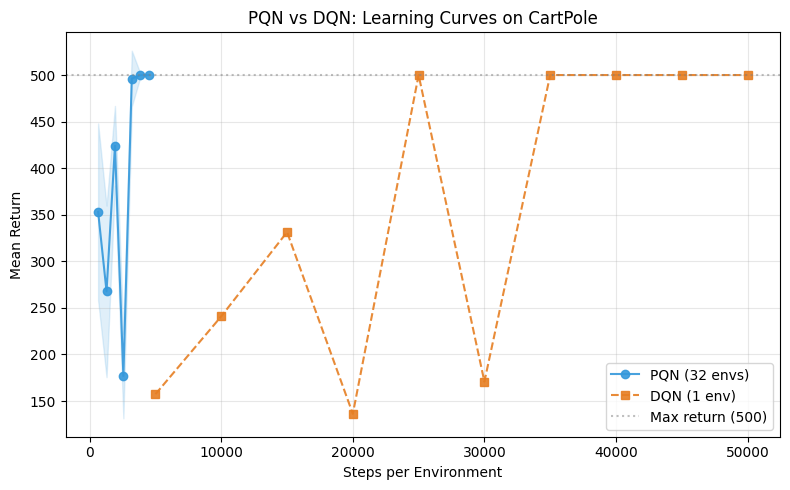

Algorithm    Envs  Steps/Env   Final Return
--------------------------------------------
PQN            32     20,000          500.0
DQN             1    100,000          500.0


In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

# PQN (32 envs): shade ±1 std across eval rollouts
steps_pqn = np.array(results_pqn.eval_metrics.steps_per_env)
mean_pqn = np.array(results_pqn.eval_metrics.mean_return)
std_pqn = np.array(results_pqn.eval_metrics.std_return)
ax.plot(steps_pqn, mean_pqn, "o-", label="PQN (32 envs)", color="#3498db", alpha=0.9)
ax.fill_between(steps_pqn, mean_pqn - std_pqn, mean_pqn + std_pqn, alpha=0.15, color="#3498db")

# DQN (1 env)
steps_dqn = np.array(results_dqn.eval_metrics.steps_per_env)
mean_dqn = np.array(results_dqn.eval_metrics.mean_return)
ax.plot(steps_dqn, mean_dqn, "s--", label="DQN (1 env)", color="#e67e22", alpha=0.9)

ax.axhline(500, color="gray", linestyle=":", alpha=0.5, label="Max return (500)")
ax.set_xlabel("Steps per Environment")
ax.set_ylabel("Mean Return")
ax.set_title("PQN vs DQN: Learning Curves on CartPole")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Algorithm':<10} {'Envs':>6} {'Steps/Env':>10} {'Final Return':>14}")
print("-" * 44)
print(f"{'PQN':<10} {32:>6} {20_000:>10,} {pqn_final_return:>14.1f}")
print(f"{'DQN':<10} {1:>6} {100_000:>10,} {dqn_final_return:>14.1f}")

## Section D: Parallelism Demo

The goal of this section is straightforward: **show that throughput (steps/sec) grows as we
add more parallel environments**.

CartPole is a trivial problem — any reasonable agent solves it quickly regardless of how many
environments run in parallel. That actually makes it a good benchmark here: task difficulty
doesn't interfere with the scaling signal, so we can isolate the effect of parallelism on
raw throughput.

What we're demonstrating is JAX's ability to vectorise environment steps and network updates
across thousands of parallel instances on a single GPU, with near-zero overhead per additional
environment. We sweep `num_envs` from 1 to 2048 and measure wall-clock throughput at each scale.

In [30]:
sweep_num_envs = [1, 32, 128, 512, 1024, 2048]
sweep_results = {}
sweep_times = {}

for num_envs in sweep_num_envs:
    print(f"Training PQN with {num_envs} parallel environment(s)...")
    config = create_config(
        agent="pqn",
        **{**PUREJAXQL_PARAMS, "num_envs": num_envs},
    )
    t0 = time.perf_counter()
    results = train_and_evaluate(config)
    elapsed = time.perf_counter() - t0

    sweep_results[num_envs] = results
    sweep_times[num_envs] = elapsed

    total = num_envs * PUREJAXQL_PARAMS["steps_per_env"]
    throughput = total / elapsed
    print(f"  final return: {results.eval_metrics.mean_return[-1]:.1f}  "
          f"time: {elapsed:.1f}s  throughput: {throughput:,.0f} steps/s\n")

Training PQN with 1 parallel environment(s)...


[14:40:46 INFO] Step  640/5000 ( 13%) | loss=0.366 | eval_return=172.48
[14:40:47 INFO] Step 1280/5000 ( 26%) | loss=0.200 | eval_return=103.34
[14:40:47 INFO] Step 1920/5000 ( 38%) | loss=0.069 | eval_return=26.85
[14:40:47 INFO] Step 2560/5000 ( 51%) | loss=0.047 | eval_return=157.43
[14:40:47 INFO] Step 3200/5000 ( 64%) | loss=0.352 | eval_return=237.59
[14:40:47 INFO] Step 3840/5000 ( 77%) | loss=0.044 | eval_return=112.72
[14:40:47 INFO] Step 4480/5000 ( 90%) | loss=0.158 | eval_return=166.22
[14:40:47 INFO] Artifacts: outputs/2026-02-23/14-40-43
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 166.2  time: 3.5s  throughput: 1,433 steps/s

Training PQN with 32 parallel environment(s)...


[14:40:50 INFO] Step  640/5000 ( 13%) | loss=0.428 | eval_return=353.06
[14:40:50 INFO] Step 1280/5000 ( 26%) | loss=0.055 | eval_return=267.77
[14:40:51 INFO] Step 1920/5000 ( 38%) | loss=0.123 | eval_return=424.05
[14:40:51 INFO] Step 2560/5000 ( 51%) | loss=0.251 | eval_return=176.80
[14:40:51 INFO] Step 3200/5000 ( 64%) | loss=0.024 | eval_return=496.23
[14:40:51 INFO] Step 3840/5000 ( 77%) | loss=0.225 | eval_return=499.70
[14:40:51 INFO] Step 4480/5000 ( 90%) | loss=0.683 | eval_return=500.00
[14:40:51 INFO] Artifacts: outputs/2026-02-23/14-40-47
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 4.0s  throughput: 40,172 steps/s

Training PQN with 128 parallel environment(s)...


...

  final return: 500.0  time: 4.4s  throughput: 585,001 steps/s

Training PQN with 1024 parallel environment(s)...


[14:41:03 INFO] Step  640/5000 ( 13%) | loss=0.400 | eval_return=430.01
[14:41:03 INFO] Step 1280/5000 ( 26%) | loss=0.144 | eval_return=500.00
[14:41:04 INFO] Step 1920/5000 ( 38%) | loss=0.583 | eval_return=500.00
[14:41:04 INFO] Step 2560/5000 ( 51%) | loss=0.149 | eval_return=483.84
[14:41:04 INFO] Step 3200/5000 ( 64%) | loss=0.295 | eval_return=500.00
[14:41:04 INFO] Step 3840/5000 ( 77%) | loss=0.973 | eval_return=500.00
[14:41:04 INFO] Step 4480/5000 ( 90%) | loss=0.264 | eval_return=500.00
[14:41:05 INFO] Artifacts: outputs/2026-02-23/14-41-00
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 5.0s  throughput: 1,026,811 steps/s

Training PQN with 2048 parallel environment(s)...


[14:41:08 INFO] Step  640/5000 ( 13%) | loss=0.408 | eval_return=455.54
[14:41:08 INFO] Step 1280/5000 ( 26%) | loss=0.220 | eval_return=475.70
[14:41:09 INFO] Step 1920/5000 ( 38%) | loss=0.501 | eval_return=500.00
[14:41:09 INFO] Step 2560/5000 ( 51%) | loss=0.693 | eval_return=500.00
[14:41:09 INFO] Step 3200/5000 ( 64%) | loss=0.488 | eval_return=500.00
[14:41:09 INFO] Step 3840/5000 ( 77%) | loss=0.477 | eval_return=500.00
[14:41:09 INFO] Step 4480/5000 ( 90%) | loss=0.537 | eval_return=500.00
[14:41:09 INFO] Artifacts: outputs/2026-02-23/14-41-05
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


  final return: 500.0  time: 4.8s  throughput: 2,145,373 steps/s



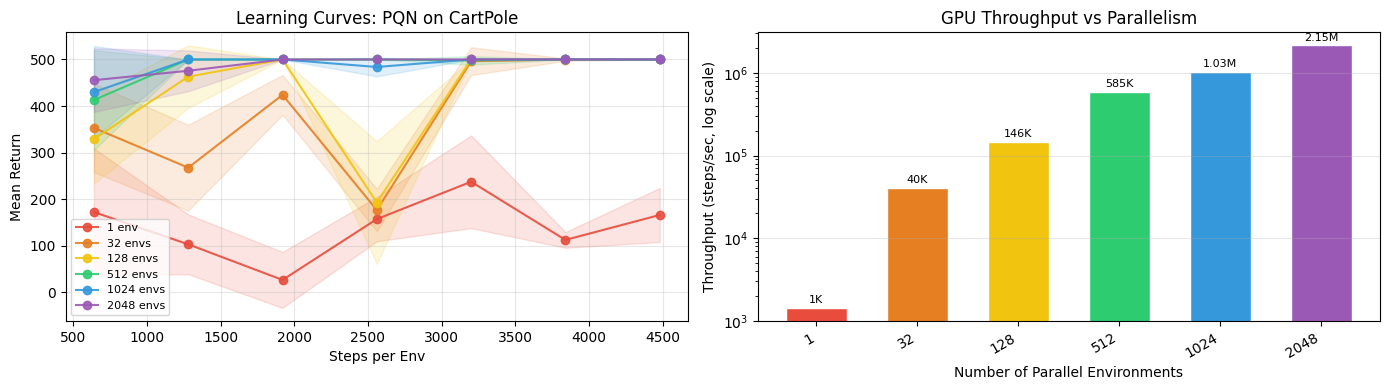

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors_sweep = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db", "#9b59b6"]

# Plot 1: Learning curves (return vs steps_per_env)
for color, num_envs in zip(colors_sweep, sweep_num_envs):
    results = sweep_results[num_envs]
    steps = results.eval_metrics.steps_per_env
    mean = results.eval_metrics.mean_return
    std = results.eval_metrics.std_return
    label = f"{num_envs} env{'s' if num_envs > 1 else ''}"
    ax1.plot(steps, mean, "o-", label=label, color=color, alpha=0.9)
    ax1.fill_between(
        steps,
        np.array(mean) - np.array(std),
        np.array(mean) + np.array(std),
        alpha=0.15,
        color=color,
    )

ax1.set_xlabel("Steps per Env")
ax1.set_ylabel("Mean Return")
ax1.set_title("Learning Curves: PQN on CartPole")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Plot 2: Throughput vs num_envs (log scale — values span 3 orders of magnitude)
steps_per_env = PUREJAXQL_PARAMS["steps_per_env"]
throughputs = [
    (n * steps_per_env) / sweep_times[n]
    for n in sweep_num_envs
]

bars = ax2.bar(
    np.arange(len(sweep_num_envs)),
    throughputs,
    color=colors_sweep,
    edgecolor="white",
    width=0.6,
)
ax2.set_xticks(np.arange(len(sweep_num_envs)))
ax2.set_xticklabels([str(n) for n in sweep_num_envs], rotation=30, ha="right")
for i, tp in enumerate(throughputs):
    ax2.text(i, tp * 1.08, f"{tp/1e6:.2f}M" if tp >= 1e6 else f"{tp/1e3:.0f}K",
             ha="center", va="bottom", fontsize=8)

ax2.set_yscale("log")
ax2.set_xlabel("Number of Parallel Environments")
ax2.set_ylabel("Throughput (steps/sec, log scale)")
ax2.set_title("GPU Throughput vs Parallelism")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

**PQN replicates PureJaxQL's results:**  
Using [PureJaxQL's published hyperparameters](https://github.com/mttga/purejaxql) verbatim,
Myriad's PQN reaches ~500 mean return on CartPole.

**PQN converges faster per environment step (Section C):**  
On a shared x-axis (steps per environment), PQN with 32 parallel environments reaches
maximum return in far fewer steps than DQN with a single environment. Large parallel batches
provide more diverse transitions and better gradient estimates per update.

**More environments → higher throughput (Section D):**  
Each jump in `num_envs` keeps wall-clock time roughly constant while processing
proportionally more transitions — GPU utilisation increases substantially with parallelism.

**PQN's no-replay-buffer design scales gracefully:**  
Adding more environments costs only rollout batch memory. DQN's replay buffer size is
fixed independently of the number of environments.

---

**References:**
- PQN paper: [Simplifying Deep Temporal Difference Learning](https://arxiv.org/abs/2407.04811)
  (Gallici et al., ICLR 2025 Spotlight)
- PureJaxQL: https://github.com/mttga/purejaxql

## Cleanup

In [32]:
for results in [results_pqn, results_dqn, *sweep_results.values()]:
    shutil.rmtree(results.run_dir, ignore_errors=True)